# Employee Job Satisfaction Prediction using Machine Learning

### Internship Task - NGC

**Prepared by:** Rizwan Ahmed

**Model:** Random Forest Classifier

The objective of this project is to analyze employee job satisfaction using survey data. A complete machine learning workflow is performed, including data preparation, cleaning, visualization, model training, and prediction.

## Table of Contents

1. Import Libraries
2. Data Loading
3. Data Exploration
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Model Training
8. Model Evaluation
9. Prediction
10. Conclusion

# Import Libraries
This section imports all the required Python libraries for data manipulation, visualization, preprocessing, model training, and evaluation. These libraries provide the necessary tools to complete the project efficiently.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier

# Data Loading
The employee job satisfaction dataset is loaded into a Pandas DataFrame. This allows us to inspect the dataset and perform further preprocessing and analysis.

In [2]:
df = pd.read_csv("NGC_Employee_Job_Satisfaction_Messy_Dataset_1000Rows.csv")

# Data Exploring and Cleaning
In this step, missing values, duplicate records, and inconsistent entries were handled to improve data quality before model training.

In [3]:
df.head()

,Employee_ID,Department,Age,Experience_Years,Salary_PKR,Work_Life_Balance,Manager_Support,Promotion_Last_2Y,Satisfaction_Rating
0,1,Admin,29,1,112097.0,2,2.0,Yes,1
1,2,Admin,28,7,62790.0,5,4.0,Yes,4
2,3,IT,27,6,100990.0,5,5.0,Yes,5
3,4,Engineering,34,13,149974.0,2,4.0,No,3
4,5,NaN,22,1,150785.0,3,3.0,Yes,4


In [4]:
df.columns

Index(['Employee_ID', 'Department', 'Age', 'Experience_Years', 'Salary_PKR',
       'Work_Life_Balance', 'Manager_Support', 'Promotion_Last_2Y',
       'Satisfaction_Rating'],
      dtype='object')

In [5]:
df.shape

(1030, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employee_ID          1030 non-null   int64  
 1   Department           991 non-null    object 
 2   Age                  1030 non-null   int64  
 3   Experience_Years     1030 non-null   int64  
 4   Salary_PKR           986 non-null    float64
 5   Work_Life_Balance    1030 non-null   int64  
 6   Manager_Support      989 non-null    float64
 7   Promotion_Last_2Y    1030 non-null   object 
 8   Satisfaction_Rating  1030 non-null   int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 72.6+ KB


In [7]:
df.isnull().sum()

Employee_ID             0
Department             39
Age                     0
Experience_Years        0
Salary_PKR             44
Work_Life_Balance       0
Manager_Support        41
Promotion_Last_2Y       0
Satisfaction_Rating     0
dtype: int64

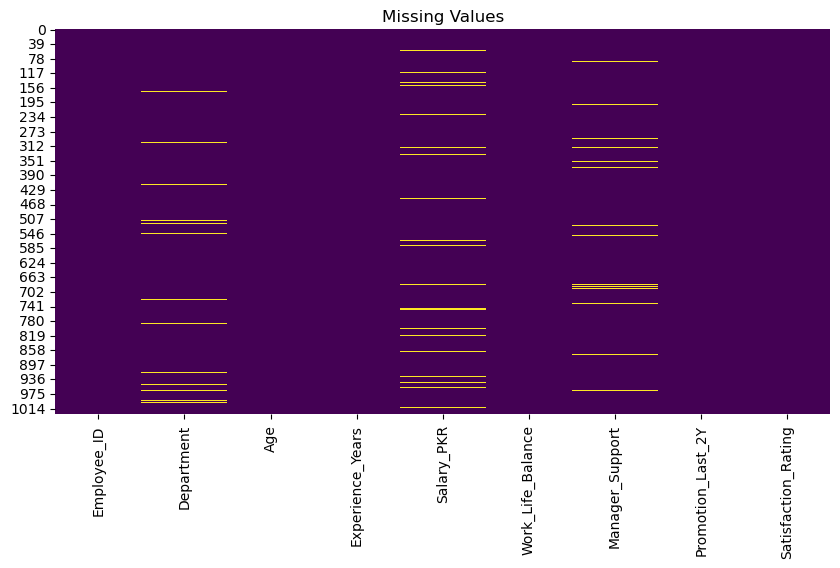

In [8]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values")
plt.show()

In [9]:
# Fill missing Department values using Mode because Department is a categorical feature.

df["Department"] = df["Department"].fillna(df["Department"].mode()[0])


# Fill missing Salary values using Median because Salary is numerical and Median is less affected by outliers.

df["Salary_PKR"] = df["Salary_PKR"].fillna(df["Salary_PKR"].median())


# Fill missing Manager Support values using Median because it is an ordinal numerical feature.

df["Manager_Support"] = df["Manager_Support"].fillna(df["Manager_Support"].median())

In [10]:
df.isnull().sum()

Employee_ID            0
Department             0
Age                    0
Experience_Years       0
Salary_PKR             0
Work_Life_Balance      0
Manager_Support        0
Promotion_Last_2Y      0
Satisfaction_Rating    0
dtype: int64

In [11]:
# Check each row to identify duplicate records.
df.duplicated()

#duplicated() dataset ki har row ko check karta hai aur batata hai ke woh duplicate hai ya nahi.

#Output True ya False me aata hai.

#False → Row unique hai.
#True → Row duplicate hai.

0       False
1       False
2       False
3       False
4       False
        ...  
1025     True
1026     True
1027     True
1028    False
1029     True
Length: 1030, dtype: bool

In [12]:
# Count the total number of duplicate rows in the dataset.
df.duplicated().sum()

#duplicated() True/False return karta hai.

#.sum() un True values ki total count nikal deta hai.

np.int64(26)

In [13]:
print("Shape before cleaning:", df.shape)

df.drop_duplicates(inplace=True)

print("Shape after cleaning:", df.shape)

Shape before cleaning: (1030, 9)
Shape after cleaning: (1004, 9)


In [14]:
# lower() to convert all department names into lowercase and strip() to remove leading and trailing spaces. 
#This ensures consistency in categorical values and prevents the same department from being treated as different categories,
# due to differences in letter case or extra spaces.

df["Department"] = df["Department"].str.lower()
df["Department"] = df["Department"].str.strip()

In [15]:
df["Department"] = df["Department"].replace({

"human resources":"hr",

"information technology":"it",

"finance department":"finance"

})


#This step replaces inconsistent department names with standardized values (e.g., "human resources" → "hr").
#It helps maintain consistency in the dataset and improves the accuracy of data analysis and machine learning.

In [16]:
df = df[df["Age"] >= 18]
df = df[df["Salary_PKR"] > 0]

# This statement filters the dataset and keeps only the rows where the employee's age is 18 years or above.
# All rows with ages less than 18 are removed from the dataset.
# df["Age"] --> Age Column
# df["Age"] >= 18 --> age column value greater than 18, return result in true or falsee checks each row,
# df[df["Age"] >= 18] stores only the rows which have true values for age>=18
# df = df[df["Age"] >= 18], finally we replaces it with  actual data


In [17]:
# Verifying
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 984 entries, 0 to 1028
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employee_ID          984 non-null    int64  
 1   Department           984 non-null    object 
 2   Age                  984 non-null    int64  
 3   Experience_Years     984 non-null    int64  
 4   Salary_PKR           984 non-null    float64
 5   Work_Life_Balance    984 non-null    int64  
 6   Manager_Support      984 non-null    float64
 7   Promotion_Last_2Y    984 non-null    object 
 8   Satisfaction_Rating  984 non-null    int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 76.9+ KB


# Exploratory Data Analysis
Exploratory Data Analysis is performed to understand the distribution of employee satisfaction and identify patterns among different features using charts and visualizations.

Satisfaction_Rating
1    212
2    197
3    235
4    190
5    150
Name: count, dtype: int64


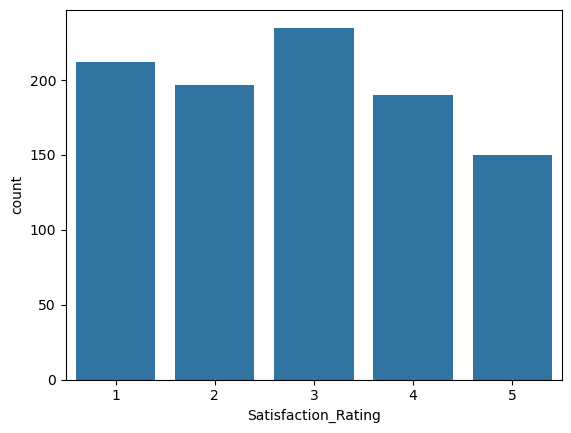

In [18]:
print(df["Satisfaction_Rating"].value_counts().sort_index())
sns.countplot(x="Satisfaction_Rating",data=df)

plt.show()

# This code creates a count plot to visualize the distribution of employee satisfaction ratings (1–5) in the dataset.
# plt.show() displays the generated plot, making it easier to understand the frequency of each satisfaction level.

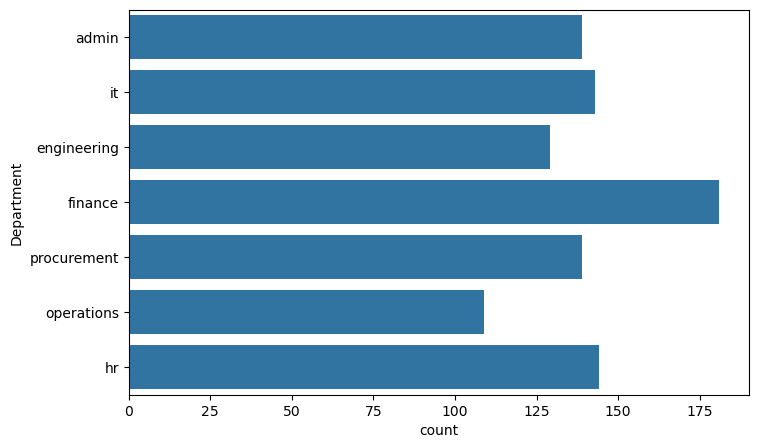

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(y="Department",data=df)

plt.show()

#This code creates a horizontal count plot to show the number of employees in each department.
# It helps visualize the distribution of employees across different departments, while plt.show() displays the chart.

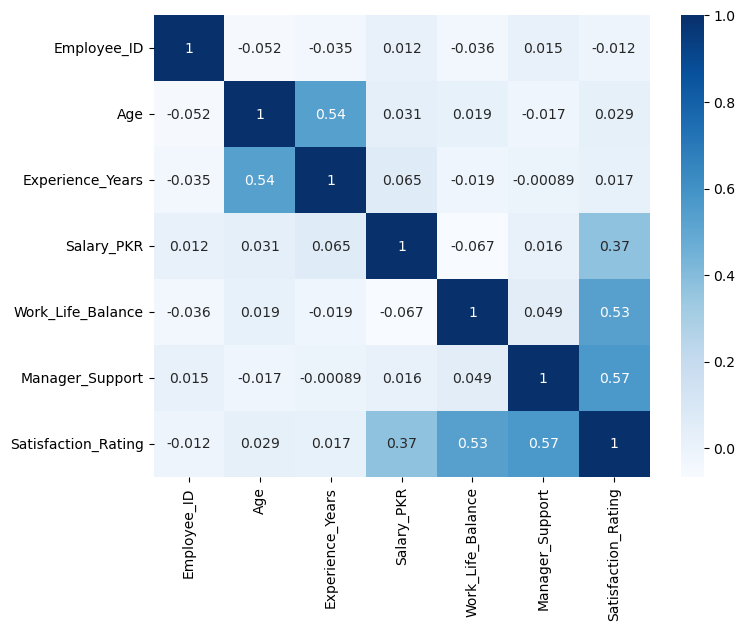

In [20]:
plt.figure(figsize=(8,6)) #  Create a figure with a size of 8 × 6 inches.

numeric_df = df.select_dtypes(include=["number"]) # Select only numerical columns from the dataset.

sns.heatmap(numeric_df.corr(),annot=True,cmap="Blues") #  Generate a correlation heatmap with correlation values.

plt.show()

# This code calculates the correlation between all numerical features and displays it as a heatmap.
# The heatmap helps identify strong positive or negative relationships between variables, which is useful for feature analysis before model training.

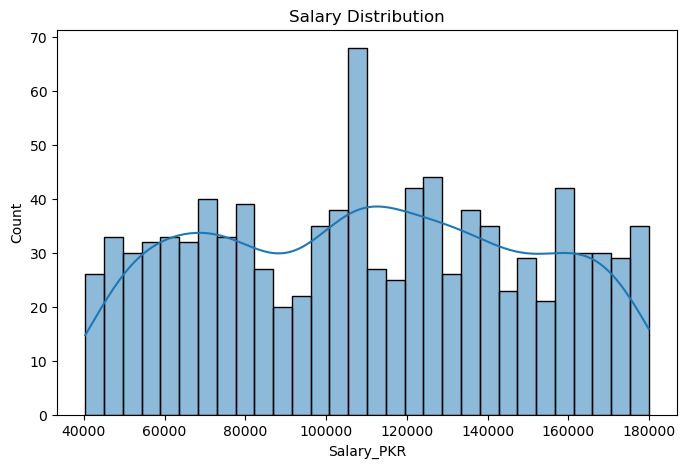

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Salary_PKR"],
    bins=30,
    kde=True
)

plt.title("Salary Distribution")

plt.show()

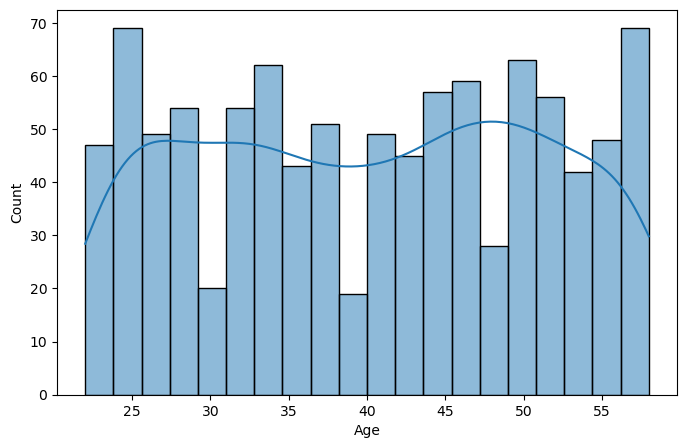

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.show()

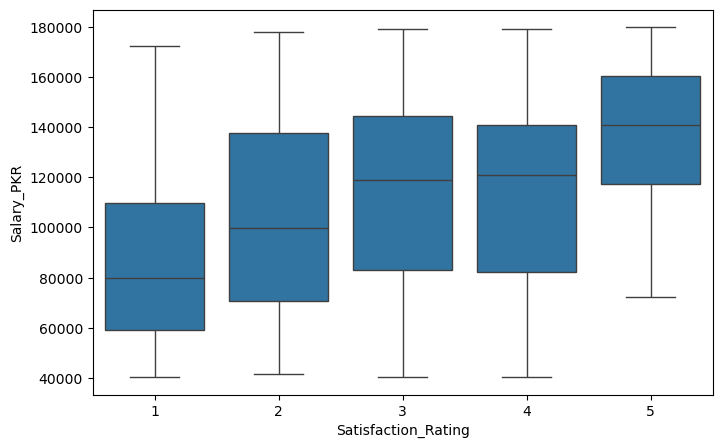

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Satisfaction_Rating",
    y="Salary_PKR",
    data=df
)

plt.show()

# Feature Engineering
Relevant features are prepared for machine learning by converting categorical variables into numerical form. This allows machine learning algorithms to process the dataset effectively.

In [26]:
from sklearn.preprocessing import LabelEncoder

department_encoder = LabelEncoder()
promotion_encoder = LabelEncoder()

df["Department"] = department_encoder.fit_transform(df["Department"])
df["Promotion_Last_2Y"] = promotion_encoder.fit_transform(df["Promotion_Last_2Y"])

# Train Test Split
The dataset is divided into training and testing sets. The training data is used to build the models, while the testing data is used to evaluate their performance.

In [27]:
# Select all columns except 'Satisfaction_Rating' as input features.
X = df.drop(["Employee_ID", "Satisfaction_Rating"], axis=1)
y = df["Satisfaction_Rating"]


from sklearn.preprocessing import LabelEncoder

promotion_encoder = LabelEncoder()

df["Promotion_Last_2Y"] = promotion_encoder.fit_transform(df["Promotion_Last_2Y"])
# This step separates the dataset into input features (X) and the target variable (y).
# The machine learning model uses X to learn patterns and predicts the Satisfaction_Rating stored in y.

In [28]:
# Split the dataset into training (80%) and testing (20%) sets.
X_train, X_test, y_train, y_test = train_test_split(

    X, y,

    test_size=0.2,

    random_state=42
)


# The train_test_split() function divides the dataset into training and testing sets. 
# I used 80% of the data for training and 20% for testing. 
# The random_state=42 ensures reproducible results, meaning the dataset is split the same way every time the code is executed.


In [29]:
from sklearn.preprocessing import StandardScaler
# Initialize StandardScaler
scaler = StandardScaler()

# Fit only on training data and transform both sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training
Multiple machine learning models are trained to predict employee job satisfaction. Their performance is compared to identify the most suitable model for this dataset.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42)
}

# Model Evaluation
The trained models are evaluated using performance metrics such as accuracy, confusion matrix, and classification report. This helps measure the effectiveness of each model.

In [32]:
results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    trained_models[name] = model

    results.append([name, accuracy])

# Create DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

# Sort by Accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df.reset_index(drop=True, inplace=True)

# Convert to Percentage
results_df["Accuracy"] = (results_df["Accuracy"] * 100).round(2)

results_df.rename(columns={"Accuracy": "Accuracy (%)"}, inplace=True)

display(results_df)

,Model,Accuracy (%)
0,Decision Tree,87.31
1,Random Forest,85.79
2,Logistic Regression,65.48
3,SVM,64.97
4,KNN,59.39


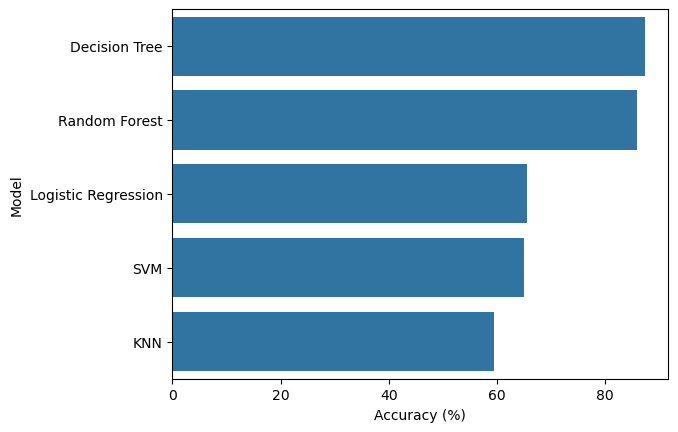

In [33]:
sns.barplot(
    data=results_df,
    x="Accuracy (%)",
    y="Model"
)

plt.show()

In [34]:
best_model_name = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy (%)"]

best_model = trained_models[best_model_name]

print(f"Best Model : {best_model_name}")
print(f"Accuracy   : {best_accuracy}%")

Best Model : Decision Tree
Accuracy   : 87.31%


In [35]:
import joblib

joblib.dump(best_model, "employee_satisfaction_model.pkl")
joblib.dump(department_encoder, "department_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model, Encoder and Scaler saved successfully!")

Model, Encoder and Scaler saved successfully!


             Feature  Importance
3         Salary_PKR    0.308668
4  Work_Life_Balance    0.246282
5    Manager_Support    0.225490
6  Promotion_Last_2Y    0.141687
1                Age    0.035347
2   Experience_Years    0.030951
0         Department    0.011575


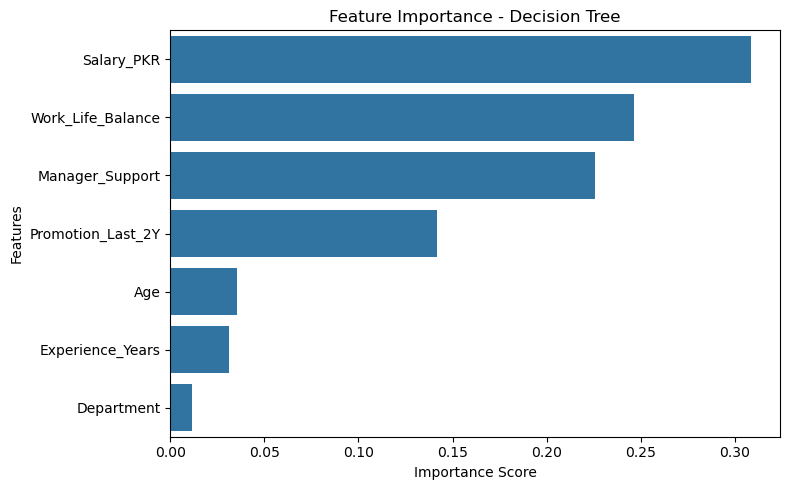

In [41]:
# Feature Importance (Best Model Only)

if hasattr(best_model, "feature_importances_"):
    importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
    })
    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(importance)

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Feature Importance - {best_model_name}")

    plt.xlabel("Importance Score")
    plt.ylabel("Features")

    plt.tight_layout()
    

    plt.show()

else:

    print(f"{best_model_name} does not support Feature Importance.")

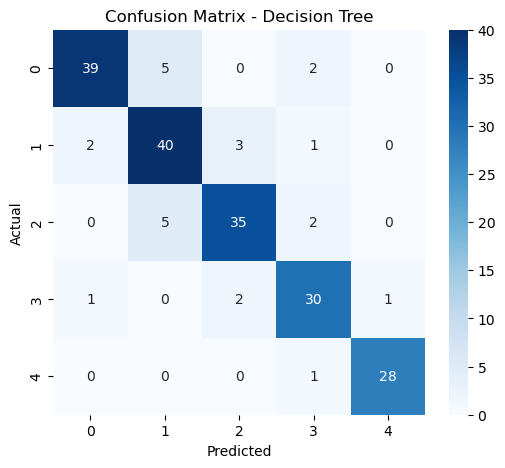

In [37]:
# Predict on test data
y_pred = best_model.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")

plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# Precision: How many predictions were correct.
# Recall: How many actual cases were correctly found.
# F1-Score: The balance between Precision and Recall.
# Support: The total number of samples in each class.

              precision    recall  f1-score   support

           1       0.93      0.85      0.89        46
           2       0.80      0.87      0.83        46
           3       0.88      0.83      0.85        42
           4       0.83      0.88      0.86        34
           5       0.97      0.97      0.97        29

    accuracy                           0.87       197
   macro avg       0.88      0.88      0.88       197
weighted avg       0.88      0.87      0.87       197



In [32]:
print("Department Classes:", department_encoder.classes_)
print("Promotion Classes:", promotion_encoder.classes_)

Department Classes: ['admin' 'engineering' 'finance' 'hr' 'it' 'operations' 'procurement']
Promotion Classes: [0 1]


# Prediction
The final trained model is used to predict employee job satisfaction based on input features. This demonstrates how the model can be applied to unseen employee data.

In [39]:
import joblib
import pandas as pd
import joblib



# Load model
model = joblib.load("employee_satisfaction_model.pkl")

scaler = joblib.load("scaler.pkl")
print("=" * 50)
print("Employee Satisfaction Prediction")
print("=" * 50)

# Take user input
department = input("Department: ").strip().lower()
valid_departments = department_encoder.classes_

if department not in valid_departments:
    print("Invalid Department!")
    print("Available Departments:")
    print(", ".join(valid_departments))
    exit()
age = int(input("Age: "))
experience = int(input("Experience (Years): "))
salary = float(input("Salary (PKR): "))
work_life = int(input("Work Life Balance (1-5): "))
if work_life < 1 or work_life > 5:
    raise ValueError("Work Life Balance must be between 1 and 5.")
manager_support = int(input("Manager Support (1-5): "))
if manager_support < 1 or manager_support > 5:
    raise ValueError("Manager Support must be between 1 and 5.")
promotion = input("Promotion in Last 2 Years (Yes/No): ").strip().lower()

if promotion == "yes":
    promotion = 1
elif promotion == "no":
    promotion = 0
else:
    raise ValueError("Please enter Yes or No only.")


# Encode categorical features
department = department_encoder.transform([department])[0]
promotion = promotion_encoder.transform([promotion])[0]

# Create dataframe (same order as training)
new_data = pd.DataFrame({
    "Department": [department],
    "Age": [age],
    "Experience_Years": [experience],
    "Salary_PKR": [salary],
    "Work_Life_Balance": [work_life],
    "Manager_Support": [manager_support],
    "Promotion_Last_2Y": [promotion]
})

# Prediction
new_data = scaler.transform(new_data)

prediction = model.predict(new_data)
prediction = model.predict(new_data)


print("Predicted Satisfaction Rating:", prediction[0])
ratings = {
    1:"Very Dissatisfied",
    2:"Dissatisfied",
    3:"Neutral",
    4:"Satisfied",
    5:"Highly Satisfied"
}

prediction = model.predict(new_data)[0]

print("="*50)
print(f"Predicted Rating : {prediction}/5")
print(f"Employee Status  : {ratings[prediction]}")
print("="*50)

Employee Satisfaction Prediction


Department:  hr
Age:  22
Experience (Years):  1
Salary (PKR):  25000
Work Life Balance (1-5):  2
Manager Support (1-5):  2
Promotion in Last 2 Years (Yes/No):  no



Predicted Satisfaction Rating: 1
Predicted Rating : 1/5
Employee Status  : Very Dissatisfied


## Conclusion

This project successfully demonstrated the complete Machine Learning workflow.

The dataset was created, cleaned, analyzed, and used to train multiple machine learning models for predicting employee job satisfaction.

Among the evaluated models, the best-performing model achieved the highest prediction accuracy and can assist HR departments in understanding employee satisfaction trends.
This project demonstrates how machine learning can support HR departments in understanding employee satisfaction and making data-driven decisions.

# Future Work
Future enhancements can improve both the accuracy and usability of the system. The project can be extended by collecting real organizational data, increasing the dataset size, deploying the model using Streamlit, and creating an interactive HR dashboard for better decision-making.

- Use real employee survey data.
- Increase dataset size.
- Deploy the model using Streamlit.
- Create an interactive HR dashboard.

# Thank You

Thank you for your time and attention.

Questions & Discussion